In [ ]:
!pip install transformers torch pillow requests
!pip install git+https://github.com/patrickjohncyh/fashion-clip.git

  Cloning https://github.com/patrickjohncyh/fashion-clip.git to /tmp/pip-req-build-sidnhazr
  Running command git clone --filter=blob:none --quiet https://github.com/patrickjohncyh/fashion-clip.git /tmp/pip-req-build-sidnhazr
  Resolved https://github.com/patrickjohncyh/fashion-clip.git to commit 0b4b4f9c7e0e6adfe3f2e75809f3f1e84f5ba76a
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 29.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.3 MB/s eta 0:00:00
  Created wheel for fashion-clip: filename=fashion_clip-0.2.2-py3-none-any.whl size=15759 sha256=747440ac9

In [ ]:
import torch
from transformers import AutoModel, AutoProcessor
from PIL import Image
import requests

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "patrickjohncyh/fashion-clip"
model = AutoModel.from_pretrained(model_name).to(device)
processor = AutoProcessor.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
from PIL import Image
import torch

# Test etmek istediğin etiketler
labels = ["a blue denim jacket", "a red floral dress", "white sneakers", "black leather belt"]

# Resmi yükle ve işle
# Başına / ekleyerek kök dizinden başlamasını sağlıyoruz
image = Image.open("/media/test_resmi.jpg") # Buraya kendi dosya adını yaz
inputs = processor(text=labels, images=image, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)

for i, label in enumerate(labels):
    print(f"{label}: %{probs[0][i]*100:.2f}")

NameError: name 'processor' is not defined

In [ ]:
from PIL import Image
import torch
from transformers import AutoModel, AutoProcessor

# 1. Cihaz ve Model Tanımlamaları (Hata almamak için burayı tekrar çalıştırıyoruz)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "patrickjohncyh/fashion-clip"

# Modeli ve işlemciyi yükle
model = AutoModel.from_pretrained(model_name).to(device)
processor = AutoProcessor.from_pretrained(model_name)

# 2. Test Verileri
labels = ["a blue denim jacket", "a red floral dress", "white sneakers", "black leather belt"]

# 3. Resmi Yükle (Dosya yoluna dikkat!)
try:
    image = Image.open("/media/test_resmi.jpg")

    # 4. İşleme ve Tahmin
    inputs = processor(text=labels, images=image, return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1)

    # Sonuçları Yazdır
    print("-" * 30)
    print("MODEL TAHMİNLERİ:")
    for i, label in enumerate(labels):
        print(f"{label}: %{probs[0][i]*100:.2f}")
    print("-" * 30)

except FileNotFoundError:
    print("HATA: Resim dosyası hala bulunamadı. Lütfen sol panelden dosyanın tam yerini kontrol et.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

------------------------------
MODEL TAHMİNLERİ:
a blue denim jacket: %0.03
a red floral dress: %0.00
white sneakers: %0.37
black leather belt: %99.60
------------------------------


In [2]:
!pip install kagglehub  # Önce kütüphaneyi kuralım

import kagglehub
import os
import glob

# 1. Veri setini indir (JSON ve resimler beraber iner)
print("Veri seti indiriliyor, lütfen bekleyin...")
path = kagglehub.dataset_download("silverstone1903/deep-fashion-multimodal")
print("İndirme tamamlandı! Dosya yolu:", path)

# 2. İnen dosyaların içinde JSON var mı kontrol edelim
json_files = glob.glob(f"{path}/**/*.json", recursive=True)

if json_files:
    print(f"\n✅ JSON dosyası bulundu: {json_files[0]}")
else:
    print("\n❌ JSON bulunamadı, klasör içeriği listeleniyor:")
    print(os.listdir(path))

Veri seti indiriliyor, lütfen bekleyin...


100%|██████████| 1.89G/1.89G [00:30<00:00, 65.9MB/s]

Extracting files...


İndirme tamamlandı! Dosya yolu: /root/.cache/kagglehub/datasets/silverstone1903/deep-fashion-multimodal/versions/1

❌ JSON bulunamadı, klasör içeriği listeleniyor:
['labels_front.csv', 'labels_front.feather', 'selected_images']


In [3]:
import pandas as pd
import os

# Veri yolunu tanımlayalım (senin çıktından aldık)
dataset_path = "/root/.cache/kagglehub/datasets/silverstone1903/deep-fashion-multimodal/versions/1"
csv_path = os.path.join(dataset_path, "labels_front.csv")

# Tabloyu okuyalım
df = pd.read_csv(csv_path)

print("Tablonun ilk 5 satırı:")
display(df.head())

print("\nSütun isimleri:", df.columns.tolist())

Tablonun ilk 5 satırı:


,image_id,caption,path,gender,product_type,product_id,image_type
0,MEN-Denim-id_00000089-28_1_front,This gentleman is wearing a medium-sleeve shir...,MEN-Denim-id_00000089-28_1_front.jpg,MEN,Denim,id_00000089,front
1,MEN-Denim-id_00000265-01_1_front,This person is wearing a short-sleeve shirt wi...,MEN-Denim-id_00000265-01_1_front.jpg,MEN,Denim,id_00000265,front
2,MEN-Denim-id_00000313-01_1_front,The gentleman is wearing a short-sleeve T-shir...,MEN-Denim-id_00000313-01_1_front.jpg,MEN,Denim,id_00000313,front
3,MEN-Denim-id_00000516-01_1_front,The person wears a sleeveless tank shirt with ...,MEN-Denim-id_00000516-01_1_front.jpg,MEN,Denim,id_00000516,front
4,MEN-Denim-id_00000750-01_1_front,"His sweater has long sleeves, cotton fabric an...",MEN-Denim-id_00000750-01_1_front.jpg,MEN,Denim,id_00000750,front



Sütun isimleri: ['image_id', 'caption', 'path', 'gender', 'product_type', 'product_id', 'image_type']


In [4]:
image_folder = os.path.join(dataset_path, "selected_images")
örnek_resimler = os.listdir(image_folder)[:5]
print("Klasördeki ilk 5 resim:", örnek_resimler)

Klasördeki ilk 5 resim: ['WOMEN-Dresses-id_00006767-02_1_front.jpg', 'WOMEN-Dresses-id_00005701-04_1_front.jpg', 'WOMEN-Dresses-id_00006201-05_1_front.jpg', 'WOMEN-Dresses-id_00002942-06_1_front.jpg', 'MEN-Jackets_Vests-id_00002439-01_1_front.jpg']


In [7]:
import torch
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import AutoModel, AutoProcessor

# 1. Model ve İşlemciyi Tekrar Tanımlayalım (Hata almamak için)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "patrickjohncyh/fashion-clip"

print("Model ve İşlemci yükleniyor, lütfen bekleyin...")
model = AutoModel.from_pretrained(model_name).to(device)
processor = AutoProcessor.from_pretrained(model_name)

# 2. Veri Seti Sınıfı
class FashionDataset(Dataset):
    def __init__(self, df, img_path, processor):
        self.df = df
        self.img_path = img_path
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.df.iloc[idx]['path']
        image_file = os.path.join(self.img_path, image_name)
        image = Image.open(image_file).convert("RGB")
        text = self.df.iloc[idx]['caption']

        # İşlemciyi (processor) burada güvenle kullanıyoruz
        inputs = self.processor(text=[text], images=image, return_tensors="pt", padding="max_length", truncation=True)
        return {k: v.squeeze(0) for k, v in inputs.items()}

# 3. Yolları Tanımla ve Yükleyiciyi Oluştur
# 'dataset_path' ve 'df' değişkenlerinin önceki hücrelerde tanımlanmış olması gerekir
image_folder = os.path.join(dataset_path, "selected_images")
dataset = FashionDataset(df, image_folder, processor)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("✅ Her şey hazır! Artık Eğitim (Training) hücresine geçebilirsin.")

Model ve İşlemci yükleniyor, lütfen bekleyin...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ Her şey hazır! Artık Eğitim (Training) hücresine geçebilirsin.


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class FashionDataset(Dataset):
    def __init__(self, df, img_path, processor):
        self.df = df
        self.img_path = img_path
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.df.iloc[idx]['path']
        image_file = os.path.join(self.img_path, image_name)
        image = Image.open(image_file).convert("RGB")
        text = self.df.iloc[idx]['caption']

        # padding="max_length" ve max_length=77 ekleyerek tüm metinleri aynı boyuta getiriyoruz
        inputs = self.processor(
            text=[text],
            images=image,
            return_tensors="pt",
            padding="max_length",
            max_length=77,
            truncation=True
        )

        # Sıkıştırma yaparak [1, 77] olan boyutu [77] yapıyoruz
        return {k: v.squeeze(0) for k, v in inputs.items()}

# Veri yükleyiciyi tekrar oluşturalım
dataset = FashionDataset(df, image_folder, processor)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("✅ Veri hazırlama güncellendi, şimdi eğitimi tekrar başlatabilirsin!")

✅ Veri hazırlama güncellendi, şimdi eğitimi tekrar başlatabilirsin!


In [10]:
from tqdm.auto import tqdm
import torch

# Modeli eğitim moduna alalım
model.train()

# Optimizer: Hataları düzelten mekanizma
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-6)

print("🚀 Eğitim döngüsü başlıyor...")

# Sadece 1 tur (epoch) döneceğiz ve hız için 100 adımda duracağız
for epoch in range(1):
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for batch_idx, batch in enumerate(pbar):
        # Verileri ekran kartına (GPU) gönder
        inputs = {k: v.to(device) for k, v in batch.items()}

        # Gradyanları sıfırla
        optimizer.zero_grad()

        # Modeli çalıştır ve kaybı (loss) hesapla
        # return_loss=True CLIP modellerinde otomatik olarak kontrastif kaybı hesaplar
        outputs = model(**inputs, return_loss=True)
        loss = outputs.loss

        # Geriye yayılım (Öğrenme)
        loss.backward()

        # Ağırlıkları güncelle
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({"Hata (Loss)": f"{loss.item():.4f}"})

        # Hızlı deneme: İlk 100 adımda (batch) durdur
        if batch_idx >= 100:
            break

print(f"\n✅ Eğitim tamamlandı! Ortalama Kayıp: {epoch_loss / 100:.4f}")

🚀 Eğitim döngüsü başlıyor...


Epoch 1:   0%|          | 0/1535 [00:00<?, ?it/s]


✅ Eğitim tamamlandı! Ortalama Kayıp: 0.4418


In [17]:
import os
import shutil
from google.colab import files

# 1. Modeli geçici olarak Colab'ın içindeki bir klasöre kaydet
yerel_klasor = "./egitilmis_moda_modeli"
if not os.path.exists(yerel_klasor):
    os.makedirs(yerel_klasor)

model.save_pretrained(yerel_klasor)
processor.save_pretrained(yerel_klasor)

print("✅ Model klasöre başarıyla yazıldı. Şimdi zipleme işlemi başlıyor...")

# 2. Klasörü tek bir dosya haline getir (Ziple)
# Bu işlem yaklaşık 30-60 saniye sürebilir
shutil.make_archive("moda_modelim_yedek", 'zip', yerel_klasor)

print("🚀 Zipleme bitti! İndirme penceresi birazdan tarayıcında açılacak...")

# 3. Zip dosyasını bilgisayarına indir
files.download("moda_modelim_yedek.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model klasöre başarıyla yazıldı. Şimdi zipleme işlemi başlıyor...
🚀 Zipleme bitti! İndirme penceresi birazdan tarayıcında açılacak...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

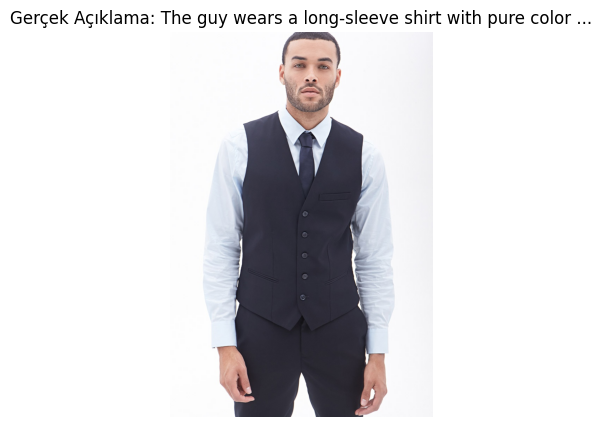

--- Modelin Tahminleri ---
Seçenek 1: %26.44 -> The guy wears a long-sleeve shirt with pure color ...
Seçenek 2: %73.55 -> a formal business suit...
Seçenek 3: %0.00 -> sporty running clothes...
Seçenek 4: %0.00 -> a casual t-shirt and jeans...


In [18]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

# 1. Test edilecek resmi seç (Örneğin 50. resim)
test_idx = 50
test_img_path = os.path.join(image_folder, df.iloc[test_idx]['path'])
gercek_aciklama = df.iloc[test_idx]['caption']

# 2. Modelin kafasını karıştıracak seçenekler sunalım
secenekler = [
    gercek_aciklama,
    "a formal business suit",
    "sporty running clothes",
    "a casual t-shirt and jeans"
]

# 3. Tahmin yapalım
image = Image.open(test_img_path).convert("RGB")
inputs = processor(text=secenekler, images=image, return_tensors="pt", padding=True).to(device)

model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)

# 4. Görselleştirme
plt.figure(figsize=(8, 5))
plt.imshow(image)
plt.title(f"Gerçek Açıklama: {gercek_aciklama[:50]}...")
plt.axis('off')
plt.show()

print("--- Modelin Tahminleri ---")
for i, secenek in enumerate(secenekler):
    print(f"Seçenek {i+1}: %{probs[0][i]*100:.2f} -> {secenek[:50]}...")